In [2]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [3]:
api = wandb.Api()

In [4]:
EXPERIMENT_GROUP = "./artifacts/2023-10-s16/distill-layerwise/run1-ch-multiple-locations"

In [6]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    arr_training_sizes,
    arr_contamination_levels,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": {"$in": arr_training_sizes}},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",

    policy="basis-identity:pca--uncentered",
    arr_training_sizes=[0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)

summary

we have 80 runs
df.shape: (4, 12)


training_size contamination_level val_acc                 val_agreement  \
                                       mean       std count          mean   
0           0.1                0.00  0.7062  0.100769    20        0.7075   
1           0.1                0.25  0.6916  0.100570    20        0.6957   
2           0.1                0.50  0.6624  0.099717    20        0.6670   
3           0.1                0.75  0.6044  0.113586    20        0.6086   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.099932    20                           0.6611  0.119973    20      0.8677  
1  0.097808    20                           0.6437  0.119231    20      0.8573  
2  0.099480    20                           0.6140  0.119636    20      0.8491  
3  0.116073    20                           0.5558  0.131218    20      0.8395

In [7]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",

    policy="basis-identity:prca-sortabs--uncentered",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)


we have 80 runs
df.shape: (4, 12)


training_size contamination_level val_acc                 val_agreement  \
                                       mean       std count          mean   
0           0.1                0.00  0.6892  0.102377    20        0.6968   
1           0.1                0.25  0.6822  0.101101    20        0.6897   
2           0.1                0.50  0.6514  0.106225    20        0.6604   
3           0.1                0.75  0.5989  0.103831    20        0.6026   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.095530    20                           0.6474  0.117488    20      0.8677  
1  0.098533    20                           0.6359  0.120089    20      0.8573  
2  0.098243    20                           0.6055  0.123307    20      0.8491  
3  0.105733    20                           0.5504  0.120526    20      0.8395

In [8]:
# def read_data_baseline(
#     teacher,
#     student,
#     lambda_task,
#     lambda_kd,
#     training_size,
#     arr_contamination_levels,
#     verbose=False,
    
# ):
#     runs = api.runs(
#         f'p16i/xaikd-distillation-layerwise-ep2',
#         {
#         "$and": [
#             {"group": EXPERIMENT_GROUP + "-baselinerun"},
#             {"config.teacher": teacher},
#             {"config.student": student},
#             {"config.lambda_task": lambda_task},
#             {"config.lambda_kd": lambda_kd},
#             {"config.policy": "basis-identity:random--uncentered"},
#             {"config.training_size": training_size},
#             {"config.contamination_level": {"$in": arr_contamination_levels}},
#         ]}
#     )
    
#     if verbose:
#         print(f"we have {len(runs)} runs")
    
#     rows = []
    
#     count = 0
#     for run in runs:
#         seed = run.config["seed"]
        
#         if "arr_metrics" not in run.summary:
#             count += 1
#             print("failed run: dataset=", run.config["dataset"])
#             continue
         
#         k = np.argmax(run.summary["arr_metrics"]["val_acc"])
#         best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
#         best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
#         best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]

#         assert run.config["lambda_layer"] is not None

#         rows.append(
#             dict(
#                 best_epoch=k,
#                 seed=seed, 
#                 lambda_task=run.config["lambda_task"],
#                 lambda_kd=run.config["lambda_kd"],
#                 lambda_layer=run.config["policy_lambda_layer"],
#                 training_size=run.config["training_size"],
#                 contamination_level=run.config["contamination_level"],

#                 val_acc=best_val_acc, 
#                 val_agreement=best_val_agreement,
#                 val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
#                 teacher_acc=run.summary["teacher_acc"],
#             )
#         )

    
#     if count > 0:
#         print(f"We have {count} failed runs")
    
    
#     df = pd.DataFrame(rows)

      
#     df = df.groupby(by=["training_size", "contamination_level"]).agg(
#         {
#             "val_acc": ["mean", "std", "count"],
#             "val_agreement": ["mean", "std", "count"],
#             "val_agreement_on_teacher_correct": ["mean", "std", "count"],
#             "teacher_acc": ["mean"]
#         }
#     ).reset_index()
    
#     np.testing.assert_allclose(
#         df["val_acc"]["count"].values,
#         20,
#         err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
#     )

#     if verbose:
#         print(f"df.shape: {df.shape}")
#     return df

# read_data_baseline(
#     teacher="cifar100-resnet18-v1",
#     student="resnet18cifarcompr2",
#     training_size=1.0,
#     arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
#     lambda_task=0.0,
#     lambda_kd=1.0
# )

# Comparison on `training-size` and `contamination-level`

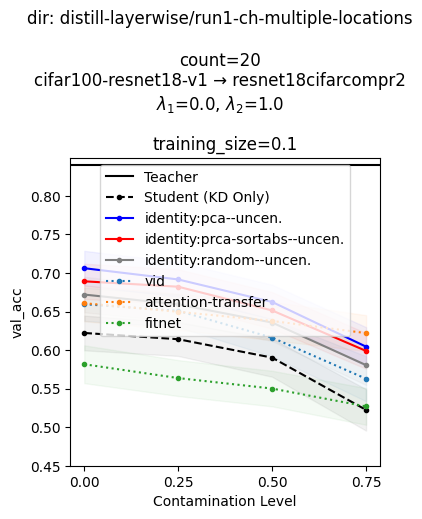

In [14]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "nothing":
        return "--"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    if "basis" in policy:
    
        return policy \
            .replace("basis-identity", "identity") \
            .replace("uncentered", "uncen.")
    
    elif policy == "nothing":
        return "Student (KD Only)"
    
    else:
        return policy

    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif policy == "nothing":
        return "black"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher, student, policies, 
    arr_training_sizes,
    arr_contamination_levels,
    show_legend=True,
    include_baseline=True
):
        
    lambda_kd = 1.0
    lambda_task = 0.0


    col = "val_acc"
    
    ncols = len(arr_training_sizes)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(nrows, ncols, tix+1)
        plt.title(f"training_size={training_size}")
        
        for pix, policy in enumerate(policies):
            df = read_data(
                teacher=teacher,
                student=student,
                policy=policy,
                
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,

                arr_training_sizes=[training_size],
                arr_contamination_levels=arr_contamination_levels,
                verbose=False
            )
            
            ticks = df["contamination_level"]

            
            # visualize baseline
            if pix == 0:

                plt.axhline(
                    df["teacher_acc"].values[-1],
                    ls="-",
                    color="k",
                    label="Teacher"
                )
                
#                 if include_baseline:
#                     df_baseline = read_data_baseline(
#                         teacher=teacher,
#                         student=student,

#                         lambda_task=lambda_task,
#                         lambda_kd=lambda_kd,

#                         training_size=training_size,
#                         arr_contamination_levels=arr_contamination_levels,
#                     )
                    
#                     plt.plot(
#                         ticks,
#                         df_baseline[col]["mean"],
#                         ls="--",
#                         color="k",
#                         label="Student (KD Only)"
#                     )
                plt.ylim(bottom=0.45, top=df["teacher_acc"].values[-1] + 0.01)
#                 plt.axhline(0.2, ls="--", color="lightgray")

            # here, we take the first value.
            # the query function already checks that the value is expected
            count = df[col]["count"].values[-1]

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)

            plt.plot(
                ticks,
                mean,
                marker=".",
                label=alias(policy),
                ls=ls(policy),
                color=color(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.05,
                color=plt.gca().lines[-1].get_color()
            )

        plt.xlabel("Contamination Level")
        plt.xticks(ticks)
        if tix==0:
            plt.ylabel(col)

            plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"count={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    arr_training_sizes=[0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
    include_baseline=True
) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set according to the hyperparameter optimization with `contamination-level=0.5` and `training-size=1.0`.

*Aims:* 
- investigate the benefit of using PRCA when varying these aspects:
    - the quality of data
    - the quantity of data

    - the size of the student model

*Conclusions:*
- So, it seems that `attention-transfer` is still better than `pca` and `prca` when contamination level is 0.75. For other values, `pca` seems to be the  bes


*Further Refinement*: 
- Currently 